In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

In [4]:
df_10 = pd.read_csv("outputs/07-10/summary.csv")
#df_13 = pd.read_csv("janus_analysis_repository/outputs/07-13/summary.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/07-10/summary.csv'

In [ ]:
df_10.columns

Index(['run_id', 'Voltage', 'AcquisitionMode', 'E_th', 'T_th',
       'gaussian_area_events', 'gaussian_area_error_events',
       'gaussian_mean_ps', 'gaussian_mean_error_ps', 'gaussian_sigma_ps',
       'gaussian_sigma_error_ps', 'CTR_ps', 'CTR_error_ps',
       'average_delay_corrected_alignments', 'bootstrap_replicates',
       'bootstrap_successful_fits', 'bootstrap_success_fraction',
       'bootstrap_duration_selected_avg_events',
       'bootstrap_duration_selected_std_events',
       'bootstrap_final_selected_avg_events',
       'bootstrap_final_selected_std_events', 'bootstrap_area_mean_events',
       'bootstrap_area_std_events', 'bootstrap_gaussian_mean_avg_ps',
       'bootstrap_gaussian_mean_std_ps', 'bootstrap_gaussian_sigma_avg_ps',
       'bootstrap_gaussian_sigma_std_ps', 'bootstrap_CTR_avg_ps',
       'bootstrap_CTR_std_ps', 'bootstrap_CTR_ci95_low_ps',
       'bootstrap_CTR_ci95_high_ps'],
      dtype='object')

In [8]:
df_oscilloscope  = pd.read_csv("janus_analysis_repository/oscilloscope_results.csv")
df_oscilloscope.head()

,voltage_V,best_ctr_ps,best_ctr_error_ps
0,45,64.2208,0.804187
1,46,63.1218,0.742333
2,47,62.9551,0.719790
3,48,62.8135,0.798787
4,49,60.5214,0.775291


In [3]:
df_threshold = df_10[df_10["V"]==46]
df_threshold.head()

NameError: name 'df_10' is not defined

C:\Users\aless\AppData\Local\Temp\ipykernel_3696\4177330662.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


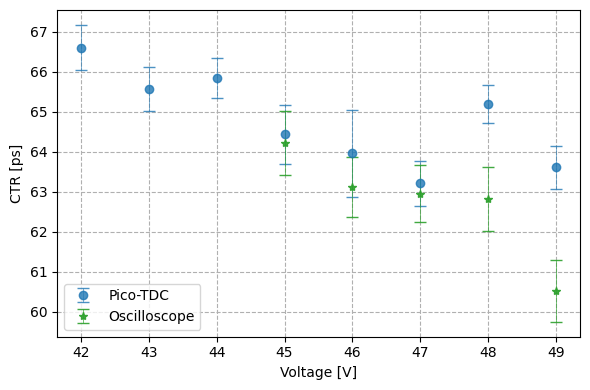

In [9]:
# --- Helper: aggregate by voltage ---
def aggregate_by_voltage(df, t_th_value):
    """
    For a given T_th, group by Voltage:
    - CTR_ps: mean of values
    - CTR_error_ps: sqrt(sum of squares of errors)
    """
    df_sel = df[df["T_th"] == t_th_value]
    agg = (
        df_sel.groupby("Voltage")
        .apply(
            lambda g: pd.Series({
                "CTR_ps_mean": g["CTR_ps"].mean(),
                "CTR_error_ps_combined": np.sqrt(np.sum(g["CTR_error_ps"]**2)),
            })
        )
        .reset_index()
    )
    return agg

# Aggregate data for T_th = 40
agg_10 = aggregate_by_voltage(df_10, t_th_value=40)

plt.figure(figsize=(6,4))

# Trigger mode
plt.errorbar(
    agg_10["Voltage"],
    agg_10["CTR_ps_mean"],
    yerr=agg_10["CTR_error_ps_combined"],
    linestyle="",
    fmt="o",
    color="C0",
    alpha=0.8,
    ecolor="C0",
    elinewidth=0.5,
    capsize=4,
    label="Pico-TDC",
)

# Oscilloscope points
plt.errorbar(
    df_oscilloscope["voltage_V"],
    df_oscilloscope["best_ctr_ps"],
    yerr= df_oscilloscope["best_ctr_error_ps"],
    marker="*",
    linestyle="",
    color="C2",
    alpha=0.9,
    elinewidth=0.5,
    capsize=4,
    label="Oscilloscope",
)
plt.xlabel("Voltage [V]")
plt.ylabel("CTR [ps]")
plt.legend(loc="lower left")
plt.tight_layout()
plt.grid(linestyle="--")
plt.show()

In [10]:
# Trova le tensioni in comune
common_voltages = np.intersect1d(agg_10["Voltage"], df_oscilloscope["voltage_V"])
# Filtro dati per tensioni comuni
agg_10_common = agg_10[agg_10["Voltage"].isin(common_voltages)].sort_values("Voltage")
osc_common = df_oscilloscope[df_oscilloscope["voltage_V"].isin(common_voltages)].sort_values("voltage_V")
x = agg_10_common["Voltage"].values
y1 = agg_10_common["CTR_ps_mean"].values
e1 = agg_10_common["CTR_error_ps_combined"].values

y2 = osc_common["best_ctr_ps"].values
e2 = osc_common["best_ctr_error_ps"].values

distance_in_sigma = np.abs(y1 - y2) / np.sqrt(e1**2 + e2**2)

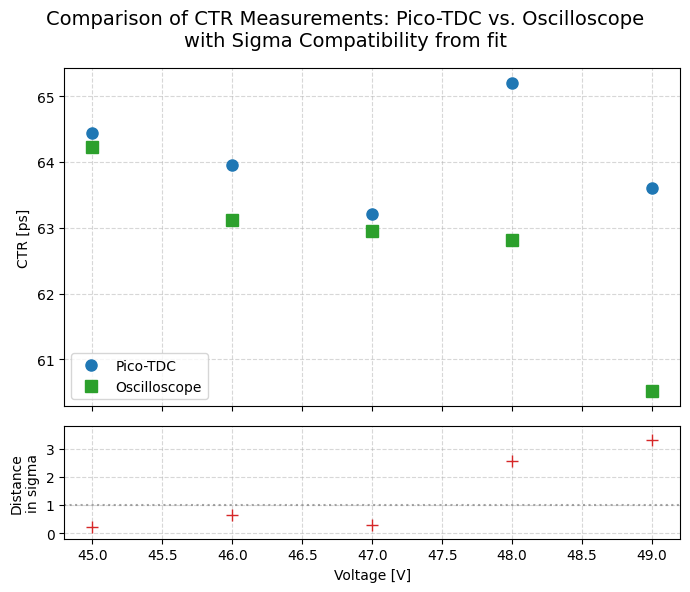

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Find voltages present in both datasets
common_voltages = np.intersect1d(agg_10["Voltage"], df_oscilloscope["voltage_V"])

# Filter and align data for these voltages
agg_10_common = agg_10[agg_10["Voltage"].isin(common_voltages)].sort_values("Voltage")
osc_common = df_oscilloscope[df_oscilloscope["voltage_V"].isin(common_voltages)].sort_values("voltage_V")

x = agg_10_common["Voltage"].values
y1 = agg_10_common["CTR_ps_mean"].values
e1 = agg_10_common["CTR_error_ps_combined"].values
y2 = osc_common["best_ctr_ps"].values
e2 = osc_common["best_ctr_error_ps"].values

distance_in_sigma = np.abs(y1 - y2) / np.sqrt(e1**2 + e2**2)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7,6), gridspec_kw={"height_ratios":[3,1]})
fig.suptitle("Comparison of CTR Measurements: Pico-TDC vs. Oscilloscope\nwith Sigma Compatibility from fit", fontsize=14)
# Main plot: CTR values without error bars
ax1.plot(x, y1, "o", markersize=8, color="C0", label="Pico-TDC")
ax1.plot(x, y2, "s", markersize=8, color="C2", label="Oscilloscope")
ax1.set_ylabel("CTR [ps]")
ax1.legend(loc="lower left")
ax1.grid(linestyle="--", alpha=0.5)

# Subplot: distance in sigma (points only, no line)
ax2.plot(x, distance_in_sigma, "+", color="C3", markersize=9)
ax2.axhline(1, linestyle=":", color="grey", alpha=0.7)  # Optional: 1 sigma guideline
ax2.set_ylabel("Distance\nin sigma")
ax2.set_ylim(0,3.8)
ax2.set_xlabel("Voltage [V]")
ax2.grid(linestyle="--", alpha=0.5)
ax2.set_ylim(bottom=-0.2)

plt.tight_layout()
plt.show()